In [1]:
import sys
sys.path.append('../')

Checking to see if the new class `RFIDataset` actually loads.

In [2]:
from samrfi import RFIDataset

In [3]:
cd /home/gpuhost002/ddeal/RFI-AI/

/home/gpuhost002/ddeal/RFI-AI


### Small test to see if a sample dataset can be created.
- First make a sample stack of synthetic rfi.

In [4]:
from samrfi import SyntheticRFI
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

dir_path = '/home/gpuhost002/ddeal/RFI-AI/'

synthetic_rfi = SyntheticRFI(min_freq=0, max_freq=256*4, min_time=0, max_time=256*4, points_freq=256*4, points_time=256*4,)

spectrographs = []
models = []

for i in range(10):
    synthetic_rfi = SyntheticRFI(min_freq=0, max_freq=256*4, min_time=0, max_time=256*4, points_freq=256*4, points_time=256*4,)
    synthetic_rfi.generate_waterfall(pers_freq_gauss=2, pers_time_gauss=2, pers_freq_square=2, pers_time_square=2,  
                                    inter_freq_square=2, inter_freq_gauss=2, noise=np.random.randint(1,10), mean=np.random.randint(3,20), mean_rfi=1000, std_rfi=500, edge_buffer=10)
    synthetic_rfi.create_model_spectrograph()
    spectrographs.append(synthetic_rfi.spectrograph)
    stat = stats.median_abs_deviation(synthetic_rfi.spectrograph, axis=None)
    median = np.median(synthetic_rfi.spectrograph)
    models.append(synthetic_rfi.model_spectrograph>(median*.1 + (stat * .2)))

spectrographs_stack = np.stack(spectrographs, axis=0)
models_stack = np.stack(models, axis=0)

dataset_images = spectrographs_stack.reshape(spectrographs_stack.shape[0], 1, spectrographs_stack.shape[1], spectrographs_stack.shape[2],)
dataset_masks = models_stack.reshape(models_stack.shape[0], 1, models_stack.shape[1], models_stack.shape[2],)

(10, 1024, 1024)


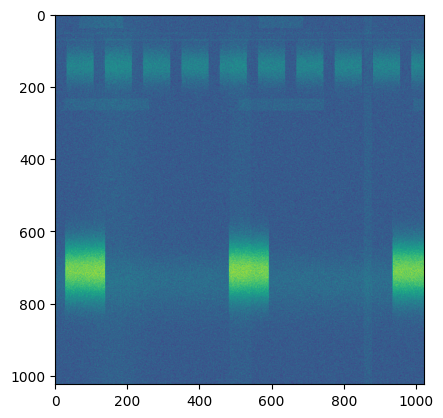

In [5]:
print(spectrographs_stack.shape)
plt.imshow(spectrographs_stack[0])

- Next, use the `RFIDataset` class to make a Dataset

In [6]:
synthetic_rfi.rfi_antenna_data = dataset_images
synthetic_rfi.flags = dataset_masks

rfi_dataset = RFIDataset(synthetic_rfi)
rfi_dataset.create_dataset(num_patches=20, patch_size=256, apply_stretching=False, custom_flag=True)


Applying median normalization only to 640 patches...


 17%|█▋        | 106/640 [00:00<00:00, 1053.95it/s]

100%|██████████| 640/640 [00:00<00:00, 961.19it/s] 


(636, 256, 256) (636, 256, 256)


In [7]:
print(rfi_dataset.patched_data_norm_only.shape)
print(rfi_dataset.patched_flags.shape)

(20, 256, 256)
(20, 256, 256)


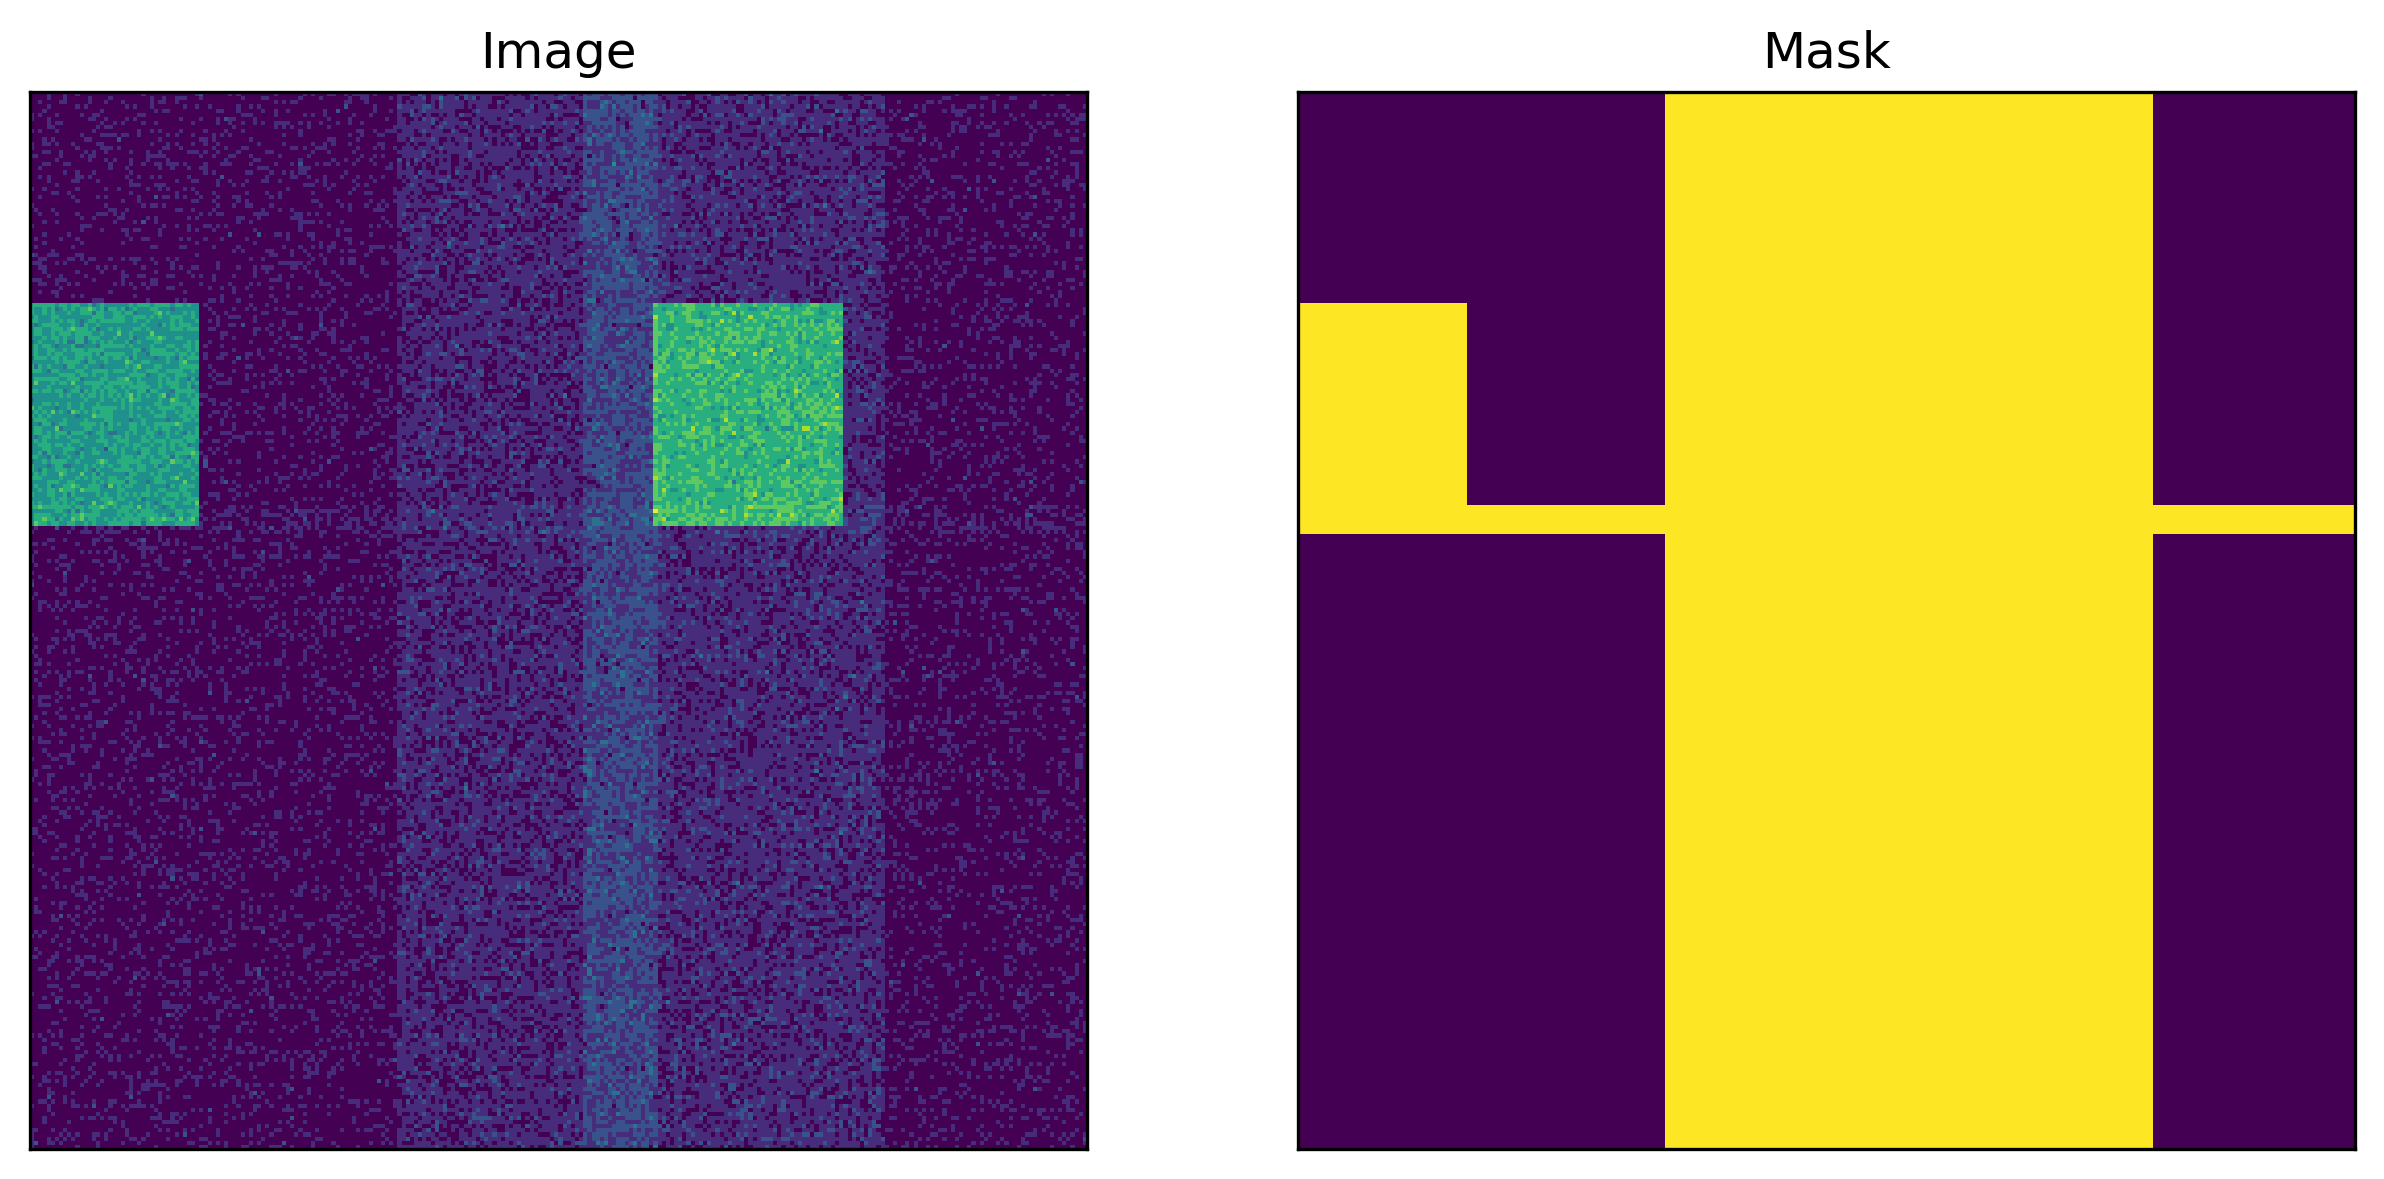

In [8]:
img_num = np.random.randint(0, 15-1)

example_image = rfi_dataset.dataset[img_num]["image"]
example_mask = rfi_dataset.dataset[img_num]["label"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

# Plot the first image on the left
axes[0].imshow(np.array(example_image).T[0],)  # Assuming the first image is grayscale
axes[0].set_title("Image")

# Plot the second image on the right
axes[1].imshow(np.array(example_mask).T,)  # Assuming the second image is grayscale
axes[1].set_title("Mask")

# Hide axis ticks and labels
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# Display the images side by side
plt.show()

In [9]:
np.array(example_image).shape

(256, 256, 3)

In [10]:
cd /home/gpuhost002/ddeal/RFI-AI/

/home/gpuhost002/ddeal/RFI-AI


Everything works as intended, so now we will use `RFITraining` to test if our dataset class works well with our training class.


Training model...


100%|██████████| 5/5 [00:12<00:00,  2.60s/it]


EPOCH: 0
Mean loss: 1.810037899017334


100%|██████████| 5/5 [00:12<00:00,  2.59s/it]


EPOCH: 1
Mean loss: 1.4520999193191528


100%|██████████| 5/5 [00:12<00:00,  2.59s/it]


EPOCH: 2
Mean loss: 1.1831526517868043


<Figure size 640x480 with 0 Axes>

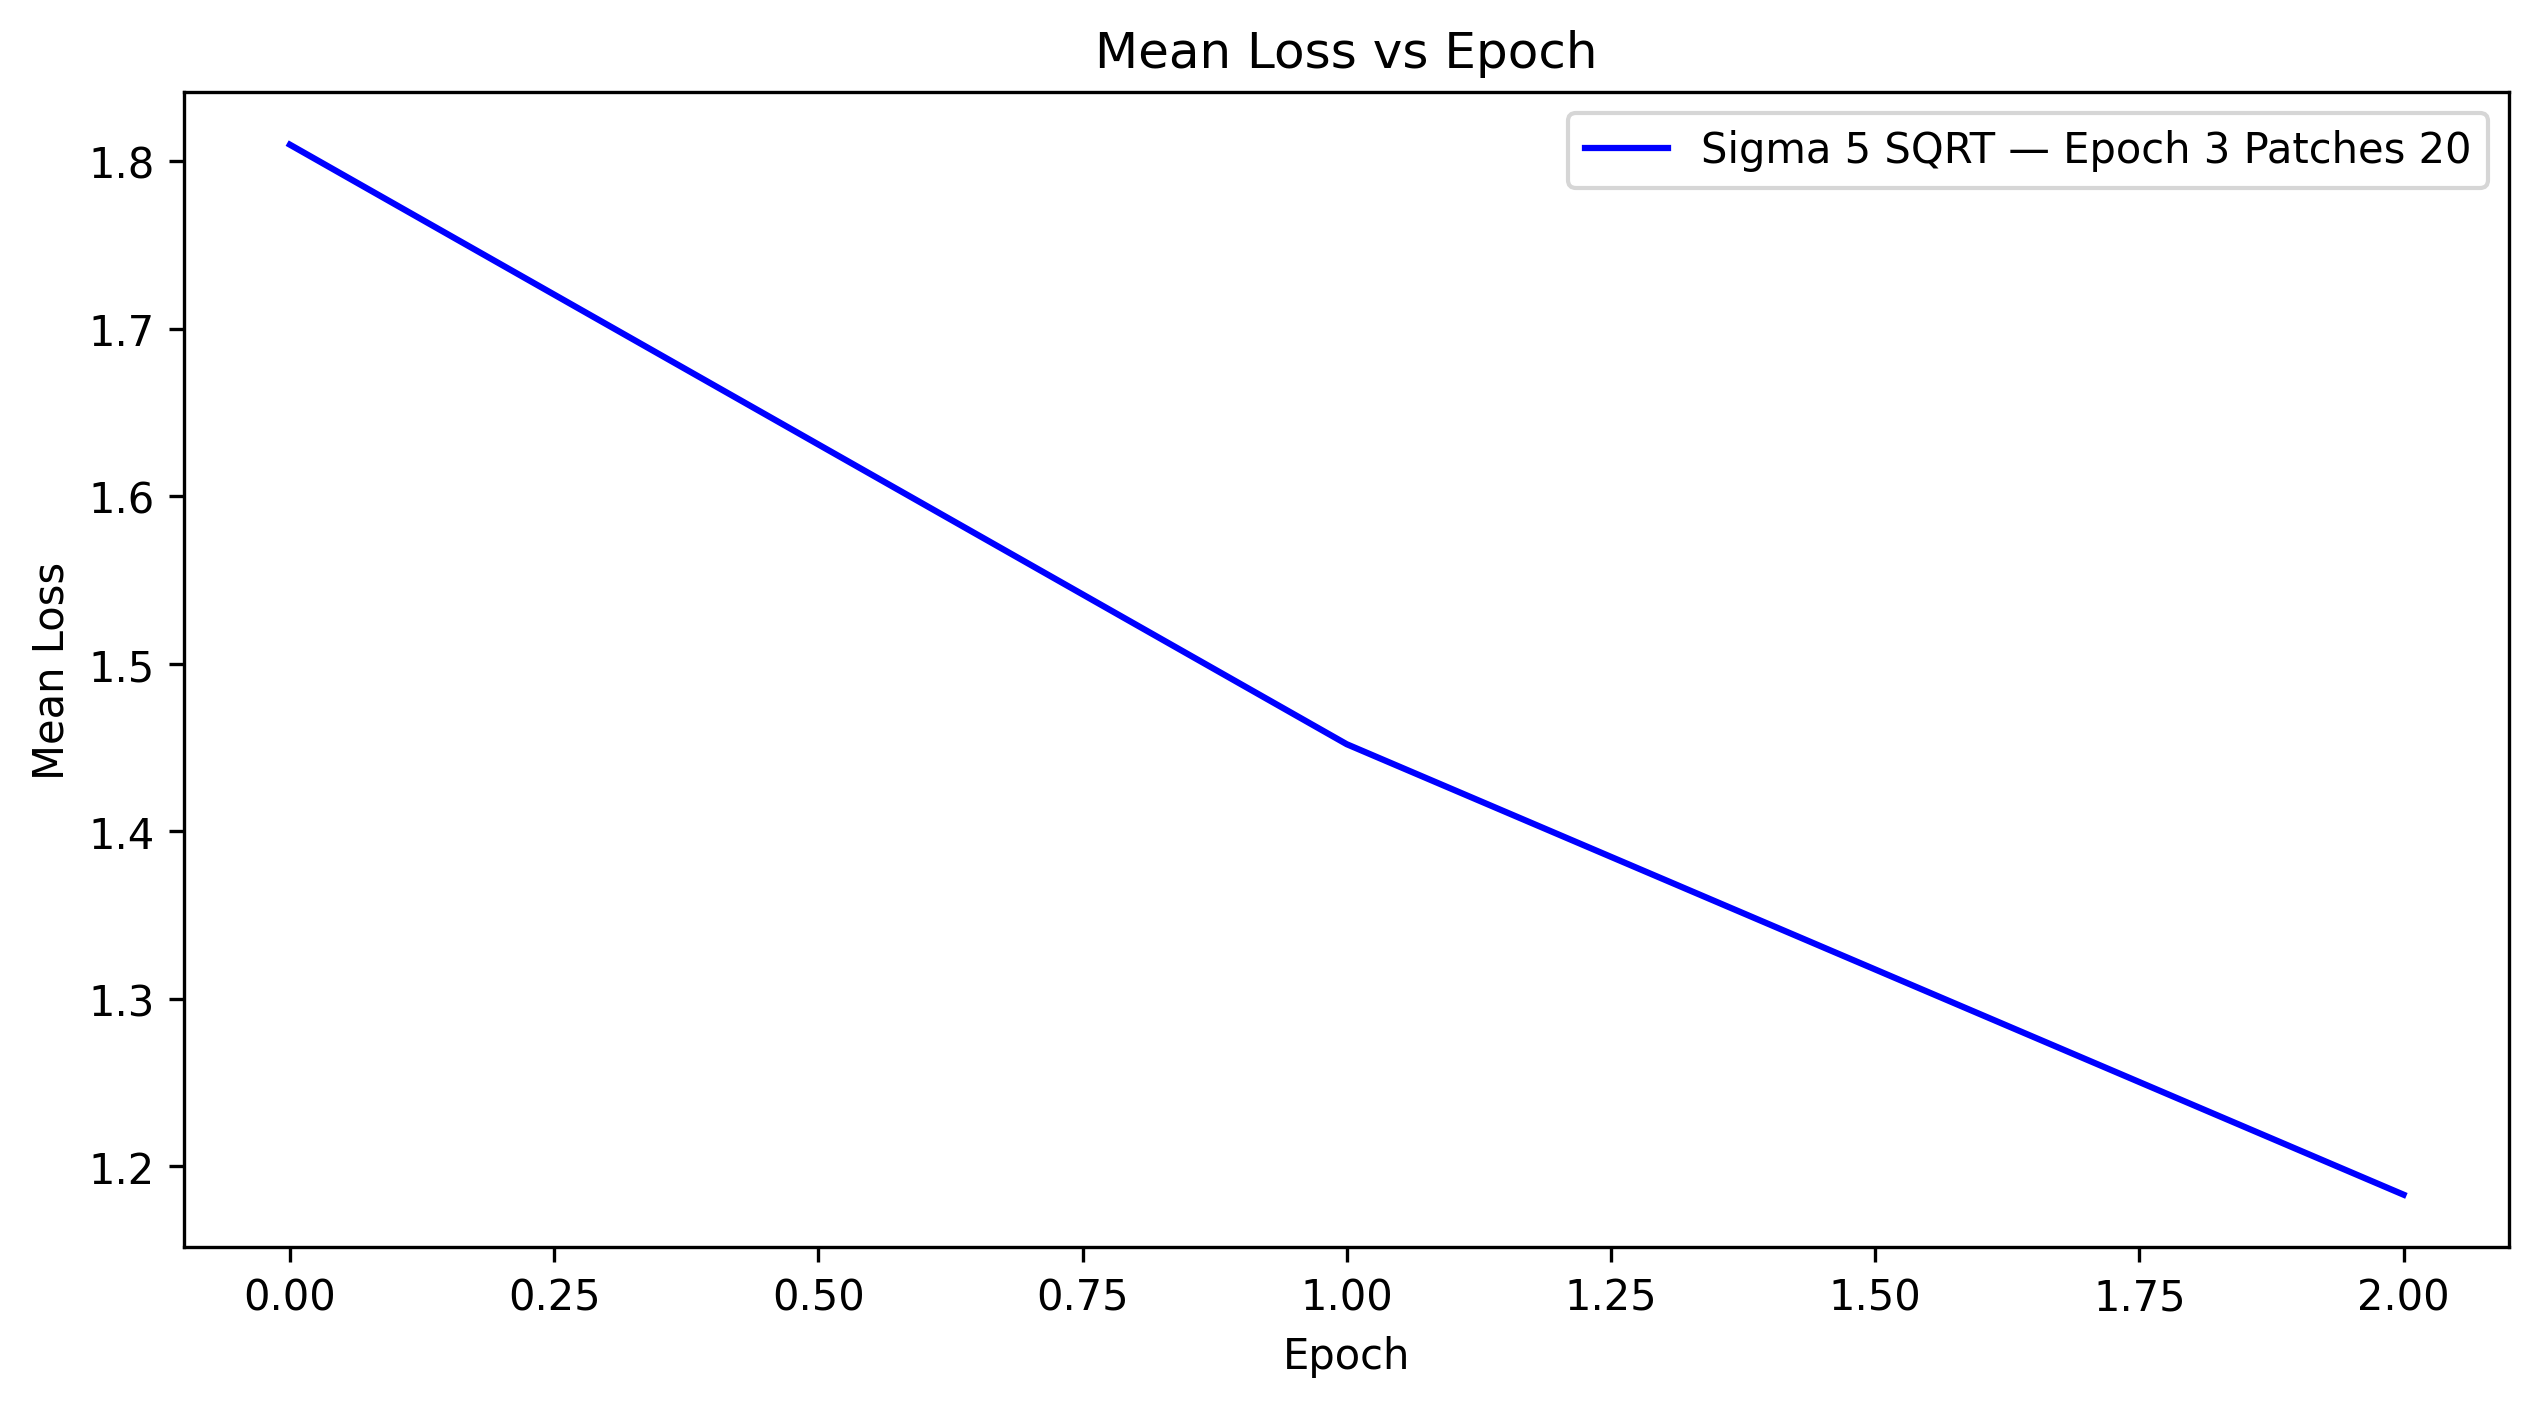

In [11]:
from samrfi import RFITraining 

new_model = RFITraining(rfi_dataset, device='cuda')
new_model.train(num_epochs=3)